# Hypothesis Testing: Cardiovascular Risk <hr style = "border:2.5px solid #e22424ff"> </hr>

<b>Amelo Jerow A.</b>
<br>T09 - A</br>

In [54]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [55]:
# load dataset
df = pd.read_csv(r"dataset\heart_attack_dataset.csv",
                 delimiter=",")
df

,Gender,Age,Blood Pressure (mmHg),Cholesterol (mg/dL),Has Diabetes,Smoking Status,Chest Pain Type,Treatment
0,Male,70,181,262,No,Never,Typical Angina,Lifestyle Changes
1,Female,55,103,253,Yes,Never,Atypical Angina,Angioplasty
2,Male,42,95,295,Yes,Current,Typical Angina,Angioplasty
3,Male,84,106,270,No,Never,Atypical Angina,Coronary Artery Bypass Graft (CABG)
4,Male,86,187,296,Yes,Current,Non-anginal Pain,Medication
...,...,...,...,...,...,...,...,...
995,Male,42,125,193,Yes,Current,Typical Angina,Angioplasty
996,Male,80,186,267,Yes,Never,Atypical Angina,Coronary Artery Bypass Graft (CABG)
997,Female,64,108,174,Yes,Current,Non-anginal Pain,Coronary Artery Bypass Graft (CABG)
998,Female,84,123,195,No,Current,Asymptomatic,Lifestyle Changes


In [56]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Gender                 1000 non-null   object
 1   Age                    1000 non-null   int64 
 2   Blood Pressure (mmHg)  1000 non-null   int64 
 3   Cholesterol (mg/dL)    1000 non-null   int64 
 4   Has Diabetes           1000 non-null   object
 5   Smoking Status         1000 non-null   object
 6   Chest Pain Type        1000 non-null   object
 7   Treatment              1000 non-null   object
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [57]:
# summary of statistics
df.describe()

,Age,Blood Pressure (mmHg),Cholesterol (mg/dL)
count,1000.000000,1000.000000,1000.000000
mean,60.338000,145.440000,223.789000
std,17.317496,31.756525,42.787817
min,30.000000,90.000000,150.000000
25%,45.000000,118.000000,185.000000
50%,60.500000,146.000000,225.500000
75%,76.000000,173.000000,259.000000
max,89.000000,199.000000,299.000000


# Data Outliers Visualization

C:\Users\Jerow Amelo\AppData\Local\Temp\ipykernel_5816\2123116078.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['Blood Pressure (mmHg)'], labels=['Blood Pressure'])


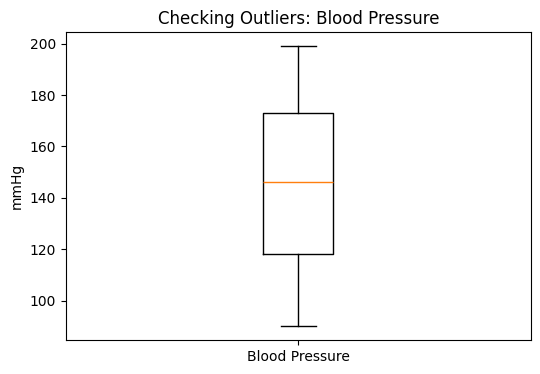

In [58]:
# plotting blood Pressure
plt.figure(figsize=(6, 4))
plt.boxplot(df['Blood Pressure (mmHg)'], labels=['Blood Pressure'])
plt.title("Checking Outliers: Blood Pressure")
plt.ylabel("mmHg")
plt.show()

C:\Users\Jerow Amelo\AppData\Local\Temp\ipykernel_5816\1355774991.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male_raw, female_raw], labels=['Male Chol', 'Female Chol'])


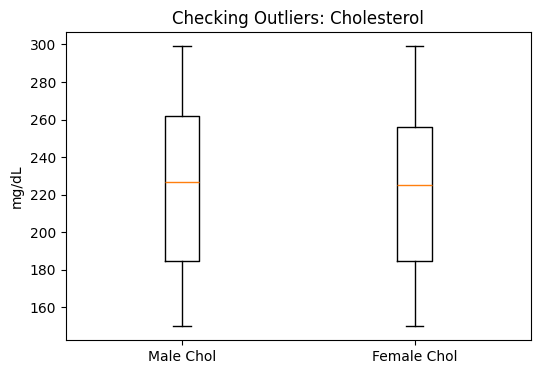

In [59]:
# plotting cholesterol by gender
male_raw = df[df['Gender'] == 'Male']['Cholesterol (mg/dL)']
female_raw = df[df['Gender'] == 'Female']['Cholesterol (mg/dL)']

plt.figure(figsize=(6, 4))
plt.boxplot([male_raw, female_raw], labels=['Male Chol', 'Female Chol'])
plt.title("Checking Outliers: Cholesterol")
plt.ylabel("mg/dL")
plt.show()

# Data Cleaning (FOR FORMALITY ONLY SIR KAY WAY NAMAN OUTLIERS AKON DATASET)

C:\Users\Jerow Amelo\AppData\Local\Temp\ipykernel_5816\2799450097.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['Blood Pressure (mmHg)'], labels=['Blood Pressure'])


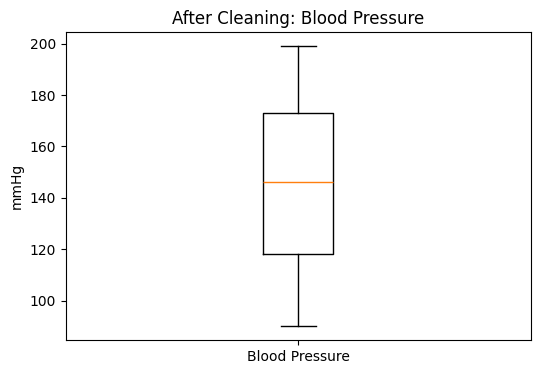

In [60]:
# removing blood pressure outliers
z_bp = stats.zscore(df['Blood Pressure (mmHg)'])
bp_outliers = (z_bp < -3) | (z_bp > 3)
df = df[~bp_outliers]

# re-plot clean blood pressure
plt.figure(figsize=(6, 4))
plt.boxplot(df['Blood Pressure (mmHg)'], labels=['Blood Pressure'])
plt.title("After Cleaning: Blood Pressure")
plt.ylabel("mmHg")
plt.show()

C:\Users\Jerow Amelo\AppData\Local\Temp\ipykernel_5816\2073247586.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male_clean, female_clean], labels=['Male Chol', 'Female Chol'])


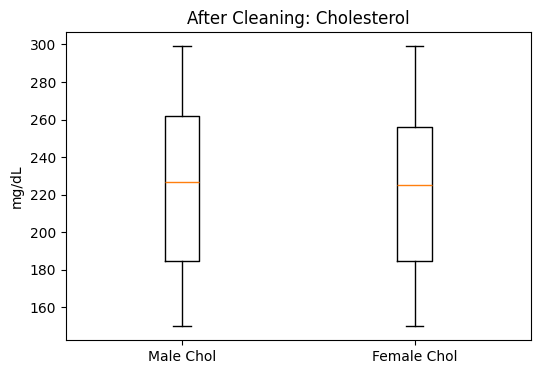

In [61]:
# rmoving cholesterol outliers
z_chol = stats.zscore(df['Cholesterol (mg/dL)'])
chol_outliers = (z_chol < -3) | (z_chol > 3)
df = df[~chol_outliers]

# re-plot clean Cholesterol
male_clean = df[df['Gender'] == 'Male']['Cholesterol (mg/dL)']
female_clean = df[df['Gender'] == 'Female']['Cholesterol (mg/dL)']

plt.figure(figsize=(6, 4))
plt.boxplot([male_clean, female_clean], labels=['Male Chol', 'Female Chol'])
plt.title("After Cleaning: Cholesterol")
plt.ylabel("mg/dL")
plt.show()

In [62]:
print(f"Dataset size after removing outliers: {df.shape[0]} rows")

Dataset size after removing outliers: 1000 rows


# NORMALIZATION (Central Limit Theorem)

In [63]:
np.random.seed(42)
n_samples = 100
sample_size = 30

bp_means, male_chol_means, female_chol_means = [], [], []

for _ in range(n_samples):
    bp_means.append(df['Blood Pressure (mmHg)'].sample(sample_size, replace=True).mean())
    male_chol_means.append(df[df['Gender'] == 'Male']['Cholesterol (mg/dL)'].sample(sample_size, replace=True).mean())
    female_chol_means.append(df[df['Gender'] == 'Female']['Cholesterol (mg/dL)'].sample(sample_size, replace=True).mean())

In [64]:
# normalized dataframe of the sample means
clt_df = pd.DataFrame({
    'BP_Means': bp_means,
    'Male_Chol': male_chol_means,
    'Female_Chol': female_chol_means
})


print(clt_df.describe())

         BP_Means   Male_Chol  Female_Chol
count  100.000000  100.000000   100.000000
mean   145.032000  224.422000   222.780000
std      6.142012    7.867500     8.202032
min    129.000000  205.066667   196.866667
25%    140.708333  218.958333   218.525000
50%    145.800000  225.066667   222.600000
75%    148.816667  229.958333   228.375000
max    158.466667  242.100000   241.066667


# 1-SAMPLE T-TEST

In [65]:
"""
1- Sample T-Test
----------------
Ho: u_bp = 120
Ha: u_bp > 120
"""
pop_mean_bp = 120
t_stat1, p_value1 = stats.ttest_1samp(clt_df['BP_Means'], pop_mean_bp, alternative='greater')
print(f'\nt_stat = {t_stat1:.4f}')
print(f'p_value = {p_value1:.4f}')

# verdict
alpha = 0.05
if p_value1 < alpha:
    # reject null hypothesis
    print("Blood Pressure is significantly higher than 120.")
else:
    # fail to reject null hypothesis
    print("Blood Pressure is not significantly higher than 120.")


t_stat = 40.7554
p_value = 0.0000
Blood Pressure is significantly higher than 120.


In [66]:
"""
right-tailed test
------------------
Ho: u_bp = 120
Ha: u_bp > 120 
"""
#standard healthy blood pressure
pop_mean = 120

# bpmeans from our CLT-normalized dataframe
t_test, p_value = stats.ttest_1samp(clt_df['BP_Means'], pop_mean,
                                    alternative='greater')

print(f"t statistic: {t_test:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("The average Blood Pressure significantly exceeds the 120 mmHg health standard.")
else:
    # fail to reject null hypothesis
    print("The average Blood Pressure meets the 120 mmHg health standard.")
    

# cohen's d
# For 1-sample, we compare the sample mean to the population mean
sample_mean = clt_df['BP_Means'].mean()
sample_std = clt_df['BP_Means'].std(ddof=1)

d = abs((sample_mean - pop_mean) / sample_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = d, 
    nobs = clt_df['BP_Means'].count(),
    alpha = 0.05,
    alternative = "larger"
)

print(f"Power of the test: {power*100:.2f}%")

t statistic: 40.7554
P-value: 0.0000
The average Blood Pressure significantly exceeds the 120 mmHg health standard.
Cohen's d: 4.0755
Power of the test: 100.00%


# 2-Sample t-Test

## Normality proof between Male Cholesterol and female choleterol

In [67]:

print("Male Cholesterol:")
w_stat_m, p_m = stats.shapiro(clt_df['Male_Chol'])
print(f"w_stat: {w_stat_m:.4f}")
print(f"P-value: {p_m:.4f}")

# verdict
alpha = 0.05
if p_m < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

print("\nFemale Cholesterol:")
w_stat_f, p_f = stats.shapiro(clt_df['Female_Chol'])
print(f"w_stat: {w_stat_f:.4f}")
print(f"P-value: {p_f:.4f}")

# verdict
if p_f < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Male Cholesterol:
w_stat: 0.9907
P-value: 0.7245
Normal data

Female Cholesterol:
w_stat: 0.9846
P-value: 0.2953
Normal data


In [68]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_male = var_female
Ha: var_male != var_female
"""

var_male = clt_df['Male_Chol'].var(ddof=1)
var_female = clt_df['Female_Chol'].var(ddof=1)

# Manual F-stat calculation
if var_male > var_female:
    f_stat = var_male / var_female
else:
    f_stat = var_female / var_male

print(f'F-statistic = {f_stat:.4f}')

# Degrees of Freedom
dof_m = clt_df['Male_Chol'].count() - 1
dof_f = clt_df['Female_Chol'].count() - 1

# probability value
p_val_f = 1 - stats.f.cdf(f_stat, dof_m, dof_f)
print(f'p-value = {p_val_f:.4f}')

# verdict
alpha = 0.05
if p_val_f < alpha:
    # reject null hypothesis
    print("unequal variances")
    use_eq_var = False
else:
    # fail to reject null hypothesis
    print("equal variances")
    use_eq_var = True

F-statistic = 1.0868
p-value = 0.3397
equal variances


In [69]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
Ho: Male_Chol <= Female_Chol
Ha: Male_Chol > Female_Chol
"""

t_stat2, p_value2 = stats.ttest_ind(clt_df['Male_Chol'], clt_df['Female_Chol'], 
                                   alternative='greater', equal_var=use_eq_var)

print(f't_stat = {t_stat2:.4f}')
print(f'p_value = {p_value2:.4f}')

# verdict
alpha = 0.05
if p_value2 < alpha:
    # reject null hypothesis
    print("Male cholesterol is significantly higher than female cholesterol.")
else:
    # fail to reject null hypothesis
    print("No significant difference between Male and Female cholesterol.")

t_stat = 1.4447
p_value = 0.0751
No significant difference between Male and Female cholesterol.


In [70]:
"""
Effect Size and Power
------------------
Ho: u_male = u_female
Ha: u_male > u_female
"""

# Manual Cohen's d formula
male_mean = clt_df['Male_Chol'].mean()
female_mean = clt_df['Female_Chol'].mean()
male_std = clt_df['Male_Chol'].std(ddof=1)

d = abs((male_mean - female_mean) / male_std)
print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = d, 
    nobs = clt_df['Male_Chol'].count(),
    alpha = 0.05,
    alternative = "larger"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 0.2087
Power of the test: 66.56%
